House Price Dataset

Why choose this?
- Real estate pricing is an important real-world problem
- The dataset contains both numerical and features

In [1]:
#Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fatinihouse_prices.csv")

In [ ]:
#Dataset Information

df.info() 
#Several columns contain missing values. Require cleaning before analysis.

df.describe()
#mean > median. Possible outliers

In [ ]:
#Missing Value

df.isna()
df.isnull().sum()
#Plot Area & Dimensions 100% missing values. Shoould remove.

In [ ]:
#Duplicate

df.duplicated()
df.duplicated().sum()
#zero duplicate

In [5]:
#Remove unnecessary column - Plot Area & Dimensions

df.drop(
    columns=["Plot Area", "Dimensions"],
    inplace=True
)

In [10]:
#Handle Missing Values

df["Price (in rupees)"] = df["Price (in rupees)"].fillna(
    df["Price (in rupees)"].median()
)

categorical_cols = [
    "Furnishing",
    "Bathroom",
    "Balcony",
    "Ownership"
]

for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

#Remove Duplicate Rows
df.drop_duplicates(inplace=True)

In [11]:
#Fix Datatypes

df["Price (in rupees)"] = pd.to_numeric(
    df["Price (in rupees)"],
    errors="coerce"
)
#ensure calc work correctly

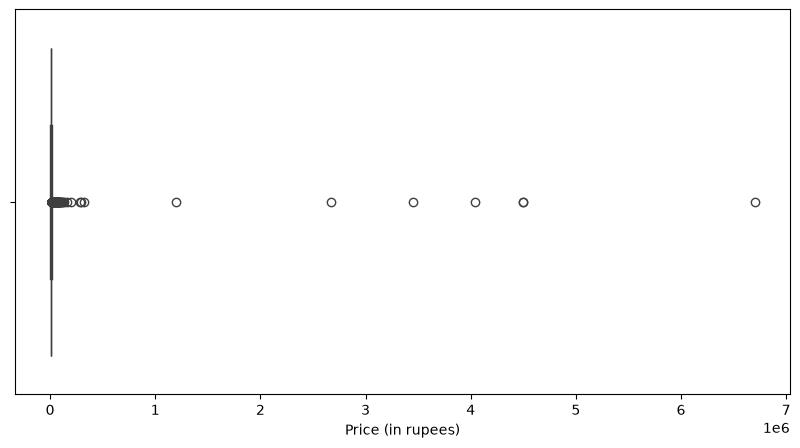

In [12]:
#Detect Outliers

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Price (in rupees)"]
)

plt.show()

In [ ]:
#Remove Outlier

Q1 = df["Price (in rupees)"].quantile(0.25)
Q3 = df["Price (in rupees)"].quantile(0.75)

print(f"Q1 : ", Q1)
print(f"Q3 : ", Q3)

IQR = Q3 - Q1

print(f'IQR : ', IQR)

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Price : ", lower)
print("Upper Price : ", upper)

outliers = df[(df["Price (in rupees)"] < lower) | (df["Price (in rupees)"] > upper)]
print(outliers)

df = df[(df["Price (in rupees)"] >= lower) & (df["Price (in rupees)"] <= upper)]
df

In [ ]:
#make sure no outlier

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Price (in rupees)"]
)

plt.show()

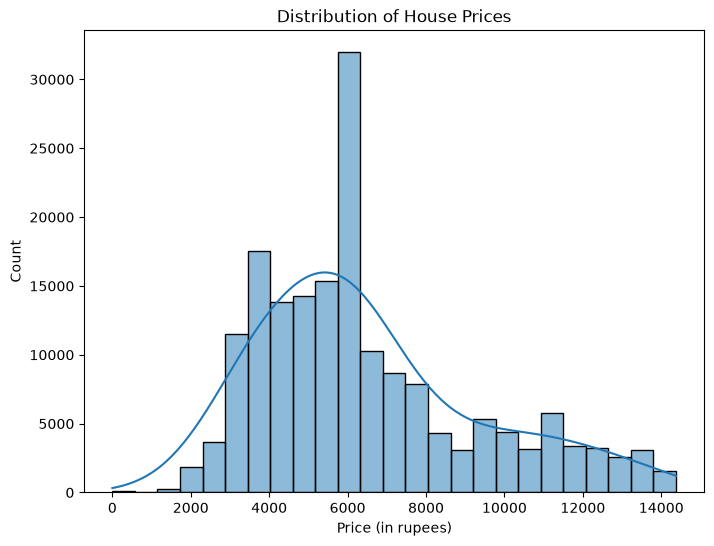

In [26]:
#Visualization

#Histogram
plt.figure(figsize=(8,6))

sns.histplot(
    df["Price (in rupees)"],
    bins=25,
    kde = True,
    kde_kws = {"bw_adjust": 5}
)

plt.title("Distribution of House Prices")
plt.show()

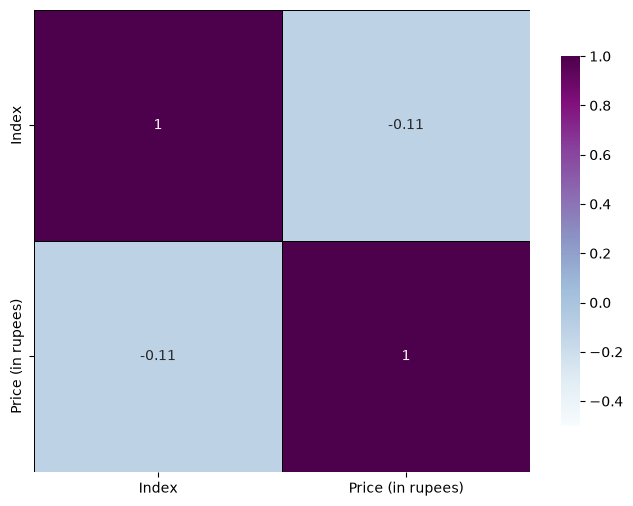

In [30]:
#Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='BuPu',
    linewidths=0.5,
    linecolor='black',
    vmin=-0.5,
    vmax=1,
    cbar_kws={"shrink": 0.8}
)
plt.show()

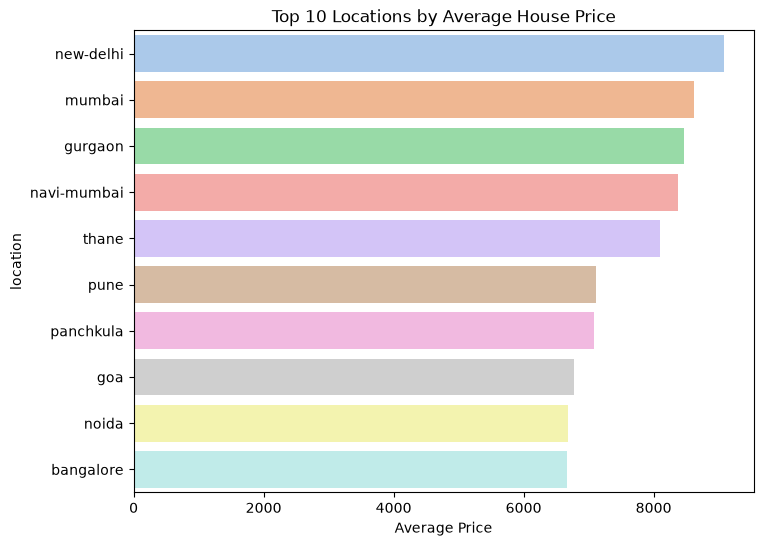

In [39]:
top10 = df.groupby("location")["Price (in rupees)"] \
          .mean() \
          .sort_values(ascending=False) \
          .head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette='pastel',
    hue=top10.index,
    legend=False
)

plt.title("Top 10 Locations by Average House Price")
plt.xlabel("Average Price")
plt.show()

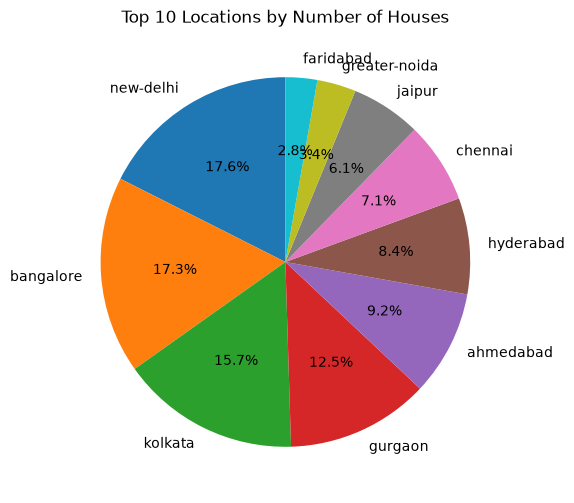

In [40]:
# Count houses by location
location_count = df['location'].value_counts().head(10)

plt.figure(figsize=(8,6))

plt.pie(
    location_count,
    labels=location_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Locations by Number of Houses")
plt.show()

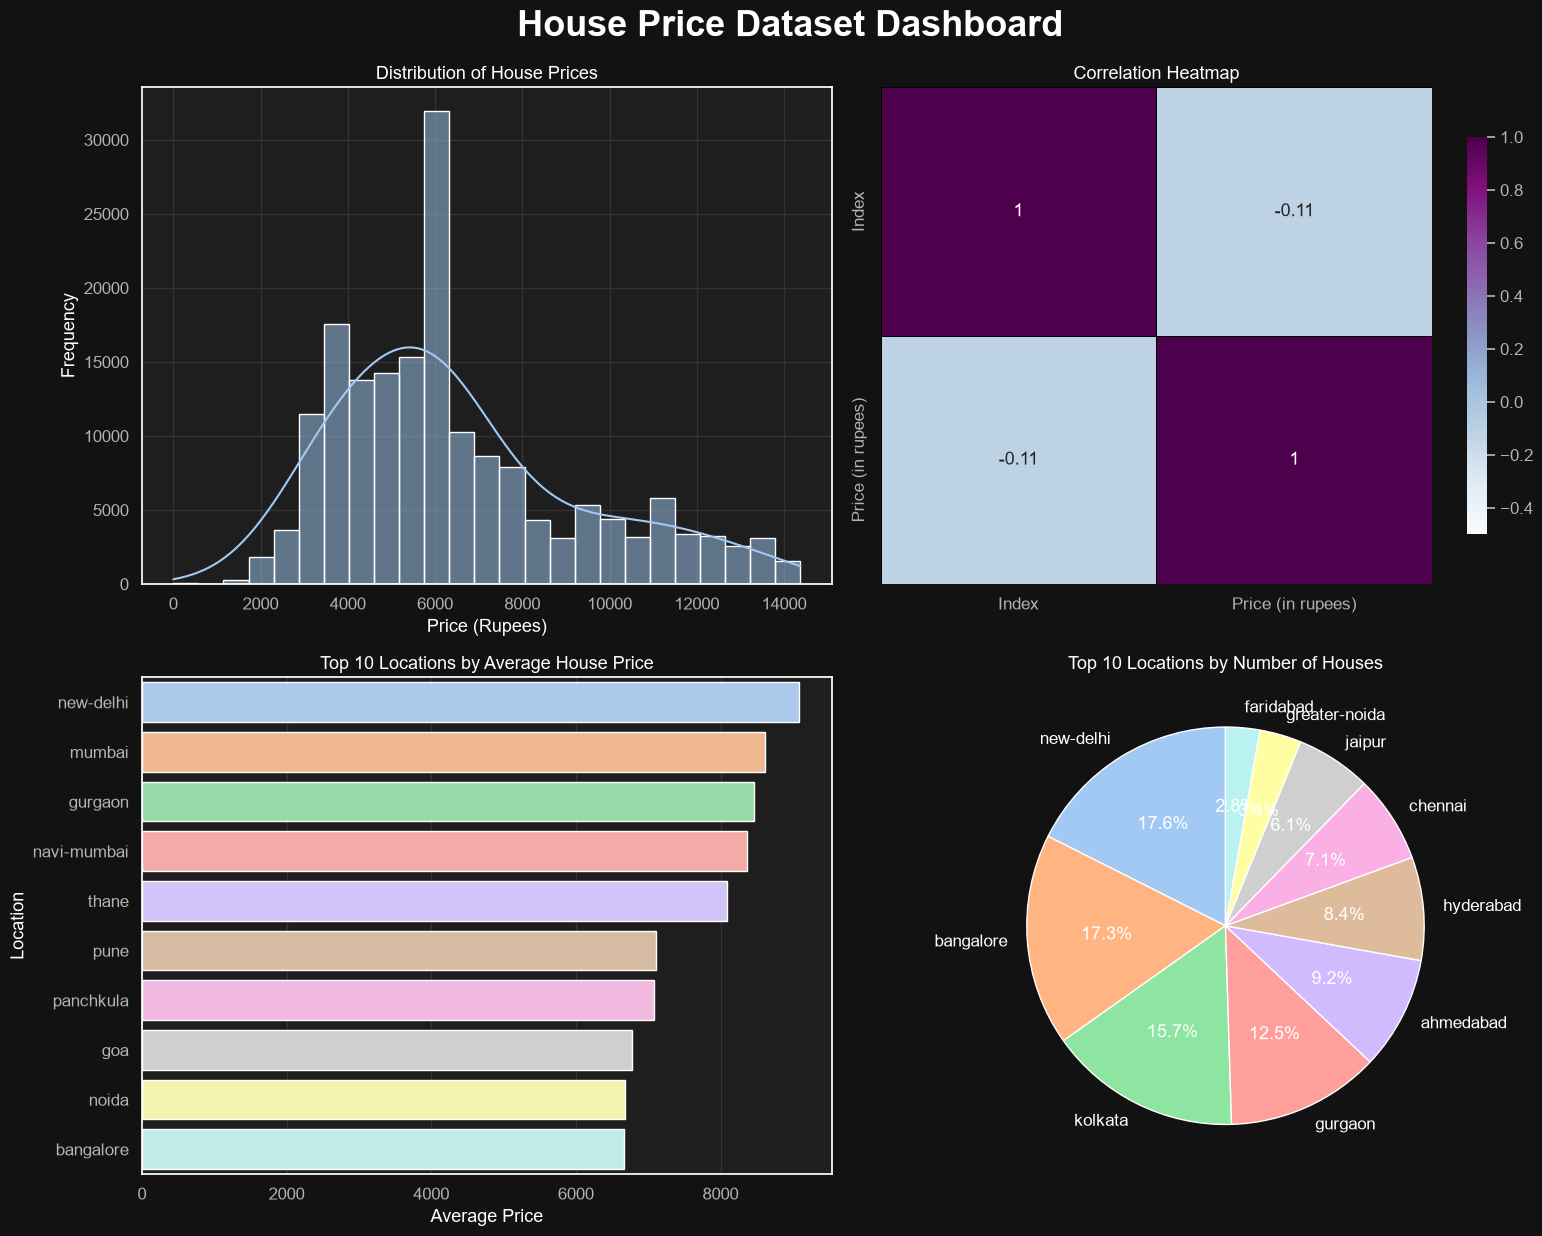

In [53]:
#Dashboard
plt.style.use('dark_background')

sns.set_theme(style= 'darkgrid',
              rc={
                "figure.facecolor": "#121212",   # Fixed: Changed from background to figure
                "axes.facecolor": "#1e1e1e",
                "grid.color": "#333333",
                "text.color": "#ffffff",
                "axes.labelcolor": "#ffffff",
                "xtick.color": "#b3b3b3",
                "ytick.color": "#b3b3b3"
                },
              palette= 'pastel',
              font= 'sans-serif',
              font_scale= 1.1,)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Histogram
sns.histplot(
    df["Price (in rupees)"],
    bins=25,
    kde=True,
    kde_kws={"bw_adjust": 5},
    ax=axes[0,0]
)

axes[0,0].set_title("Distribution of House Prices")
axes[0,0].set_xlabel("Price (Rupees)")
axes[0,0].set_ylabel("Frequency")

#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='BuPu',
    linewidths=0.5,
    linecolor='black',
    vmin=-0.5,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=axes[0,1]
)

axes[0,1].set_title("Correlation Heatmap")

#Bar Chart
top10 = df.groupby("location")["Price (in rupees)"] \
          .mean() \
          .sort_values(ascending=False) \
          .head(10)

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette='pastel',
    hue=top10.index,
    legend=False,
    ax=axes[1,0]
)

axes[1,0].set_title("Top 10 Locations by Average House Price")
axes[1,0].set_xlabel("Average Price")
axes[1,0].set_ylabel("Location")

#Pie Chart
location_count = df['location'].value_counts().head(10)

axes[1,1].pie(
    location_count,
    labels=location_count.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[1,1].set_title("Top 10 Locations by Number of Houses")

plt.tight_layout()

fig.suptitle(
    "House Price Dataset Dashboard",
    fontsize=26,
    fontweight='bold',
    y=1.03
)

plt.show()